# 03 Monthly Salience-Polling Merge

 Here we merge monthly media salience indicators with monthly afd bundestag polling data fetched from DAWUM



In [10]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'data'
INDICATORS_DIR = DATA_DIR / 'indicators'
POLLING_DIR = DATA_DIR / 'polling' / 'processed'
PANEL_DIR = DATA_DIR / 'panel'
FIGURES_DIR = PROJECT_ROOT / 'figures' / '03_notebook_figures'

for d in [PANEL_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

MEDIA_PARQUET_PATH = INDICATORS_DIR / 'monthly_media_salience_indicator.parquet'
MEDIA_CSV_PATH = INDICATORS_DIR / 'monthly_media_salience_indicator.csv'

POLL_PARQUET_PATH = POLLING_DIR / 'afd_polling_monthly_2017_2025.parquet'
POLL_CSV_PATH = POLLING_DIR / 'afd_polling_monthly_2017_2025.csv'

PANEL_CSV_PATH = PANEL_DIR / 'monthly_salience_polling_panel.csv'
PANEL_PARQUET_PATH = PANEL_DIR / 'monthly_salience_polling_panel.parquet'

ANALYSIS_START = pd.Timestamp('2017-01-01')
ANALYSIS_END = pd.Timestamp('2025-12-31')
EXPECTED_MONTHS = pd.period_range(ANALYSIS_START, ANALYSIS_END, freq='M')

CHEMNITZ_MONTH = pd.Timestamp('2018-08-01')
CORRECTIV_MONTH = pd.Timestamp('2024-01-01')

In [11]:
def load_table(preferred_parquet: Path, fallback_csv: Path) -> pd.DataFrame:
    if preferred_parquet.exists():
        return pd.read_parquet(preferred_parquet)
    if fallback_csv.exists():
        return pd.read_csv(fallback_csv)
    raise FileNotFoundError(f'Missing both parquet and csv: {preferred_parquet} | {fallback_csv}')

media = load_table(MEDIA_PARQUET_PATH, MEDIA_CSV_PATH)
polling = load_table(POLL_PARQUET_PATH, POLL_CSV_PATH)

In [12]:
def ensure_month_keys(df: pd.DataFrame, name: str) -> pd.DataFrame:
    out = df.copy()

    if 'year_month' in out.columns:
        out['year_month'] = out['year_month'].astype(str)
    elif 'month' in out.columns:
        out['year_month'] = out['month'].astype(str)
    else:
        raise ValueError(f'{name}: missing both year_month and month columns')

    if 'month_dt' in out.columns:
        out['month_dt'] = pd.to_datetime(out['month_dt'], errors='coerce')
    else:
        out['month_dt'] = pd.to_datetime(out['year_month'] + '-01', errors='coerce')

    out['year_month'] = out['month_dt'].dt.strftime('%Y-%m')
    out['month'] = out['year_month']

    if out['month_dt'].isna().any():
        bad = out.loc[out['month_dt'].isna(), ['year_month']].head(10)
        raise ValueError(f'{name}: month_dt parsing failed for rows: {bad.to_dict(orient="records")}')

    if out['year_month'].duplicated().any():
        dupes = out.loc[out['year_month'].duplicated(), 'year_month'].tolist()
        raise ValueError(f'{name}: duplicate month keys: {dupes[:10]}')

    out = out.sort_values('month_dt').reset_index(drop=True)
    return out

media = ensure_month_keys(media, 'media')
polling = ensure_month_keys(polling, 'polling')


if media['month_dt'].min().to_period('M') > ANALYSIS_START.to_period('M') or media['month_dt'].max().to_period('M') < ANALYSIS_END.to_period('M'):
    raise ValueError('Media salience does not cover required analysis window months 2017-01 to 2025-12')

polling_window = polling[(polling['month_dt'] >= ANALYSIS_START) & (polling['month_dt'] <= ANALYSIS_END)].copy()
if polling_window.empty:
    raise ValueError('Polling data has no rows inside analysis window 2017-01 to 2025-12')

poll_months = pd.PeriodIndex(polling_window['month_dt'].dt.to_period('M').unique(), freq='M')
missing_poll_months = EXPECTED_MONTHS.difference(poll_months)

In [13]:
media_window = media[(media['month_dt'] >= ANALYSIS_START) & (media['month_dt'] <= ANALYSIS_END)].copy()
media_window = media_window.sort_values('month_dt').reset_index(drop=True)

if len(media_window) != len(EXPECTED_MONTHS):
    raise ValueError(f'Media window rows mismatch: expected {len(EXPECTED_MONTHS)}, got {len(media_window)}')

media_months = pd.PeriodIndex(media_window['month_dt'].dt.to_period('M').unique(), freq='M')
missing_media_months = EXPECTED_MONTHS.difference(media_months)
if len(missing_media_months) > 0:
    raise ValueError('Missing media months in analysis window: ' + ', '.join(m.strftime('%Y-%m') for m in missing_media_months))

In [14]:
panel = polling.merge(
    media_window,
    on='year_month',
    how='inner',
    suffixes=('', '_media'),
    validate='one_to_one',
)

                                           
if 'month_dt' not in panel.columns and 'month_dt_media' in panel.columns:
    panel['month_dt'] = panel['month_dt_media']
if 'month' not in panel.columns and 'month_media' in panel.columns:
    panel['month'] = panel['month_media']

panel['month_dt'] = pd.to_datetime(panel['month_dt'], errors='coerce')
panel['month'] = panel['month_dt'].dt.strftime('%Y-%m')
panel['year_month'] = panel['month']

if panel['year_month'].duplicated().any():
    dupes = panel.loc[panel['year_month'].duplicated(), 'year_month'].tolist()
    raise ValueError(f'Panel has duplicate month keys: {dupes[:10]}')

if len(panel) != len(EXPECTED_MONTHS):
    raise ValueError(f'Panel rows mismatch: expected {len(EXPECTED_MONTHS)}, got {len(panel)}')

if panel['afd_poll_support_mean'].isna().any():
    raise ValueError('Missing afd_poll_support_mean after merge')

if panel['nexis_total_results'].isna().any():
    raise ValueError('Missing nexis_total_results after merge')

if 'retrieval_mismatch_flag' in panel.columns:
    mismatch_count = int(panel['retrieval_mismatch_flag'].fillna(False).astype(bool).sum())
    if mismatch_count != 0:
        raise ValueError(f'retrieval_mismatch_flag has {mismatch_count} True values in merged panel')

panel = panel.sort_values('month_dt').reset_index(drop=True)

In [15]:
def zscore(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors='coerce')
    mu = s.mean()
    sd = s.std(ddof=0)
    if pd.isna(sd) or sd == 0:
        return pd.Series(np.zeros(len(s)), index=s.index, dtype=float)
    return (s - mu) / sd

panel['afd_poll_support_z'] = zscore(panel['afd_poll_support_mean'])

if 'media_salience_volume_z' not in panel.columns:
    panel['media_salience_volume_z'] = zscore(panel['nexis_total_results'])

if 'media_salience_volume_log1p' not in panel.columns:
    panel['media_salience_volume_log1p'] = np.log1p(pd.to_numeric(panel['nexis_total_results'], errors='coerce'))

panel['month_index'] = np.arange(len(panel), dtype=int)

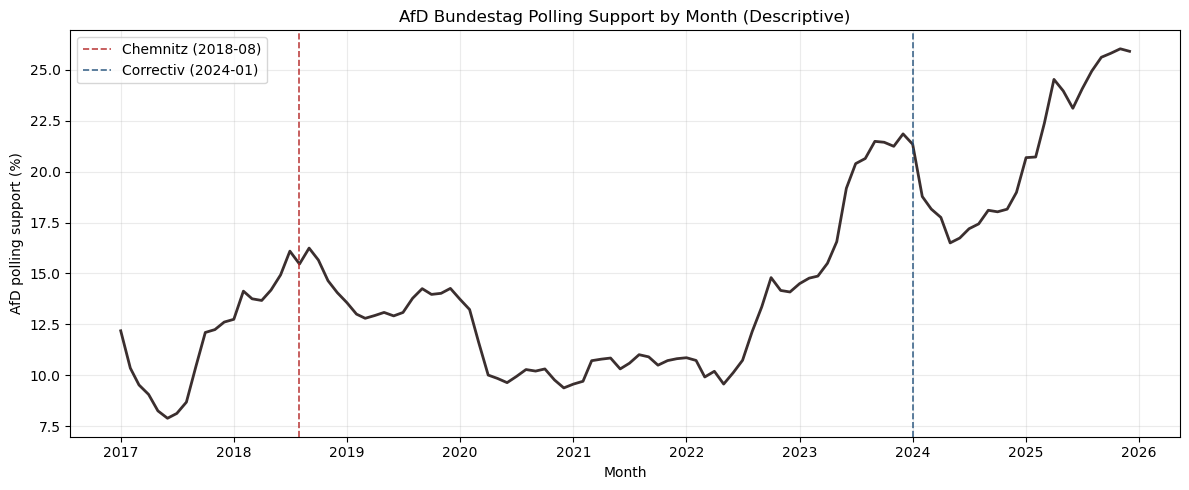

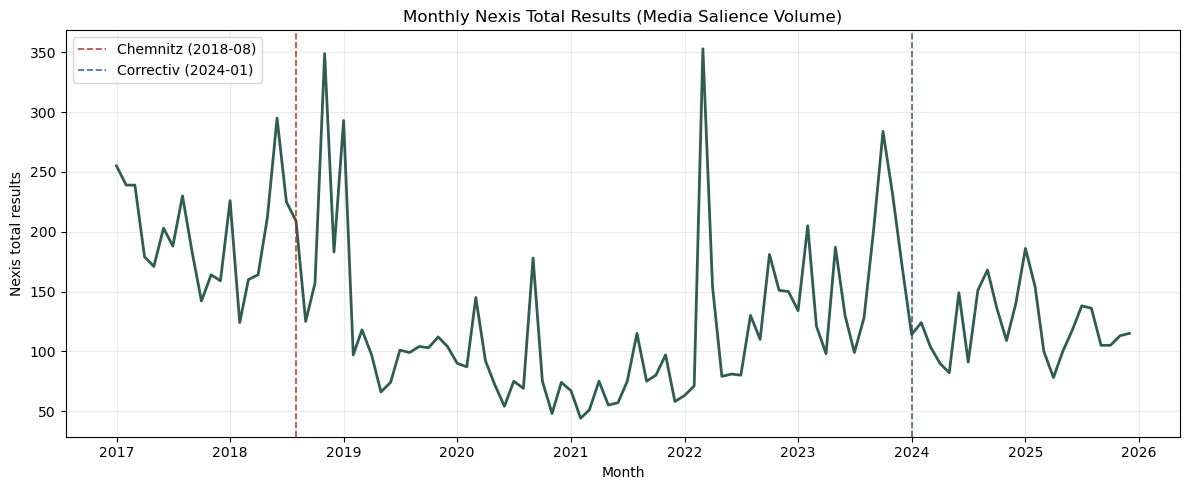

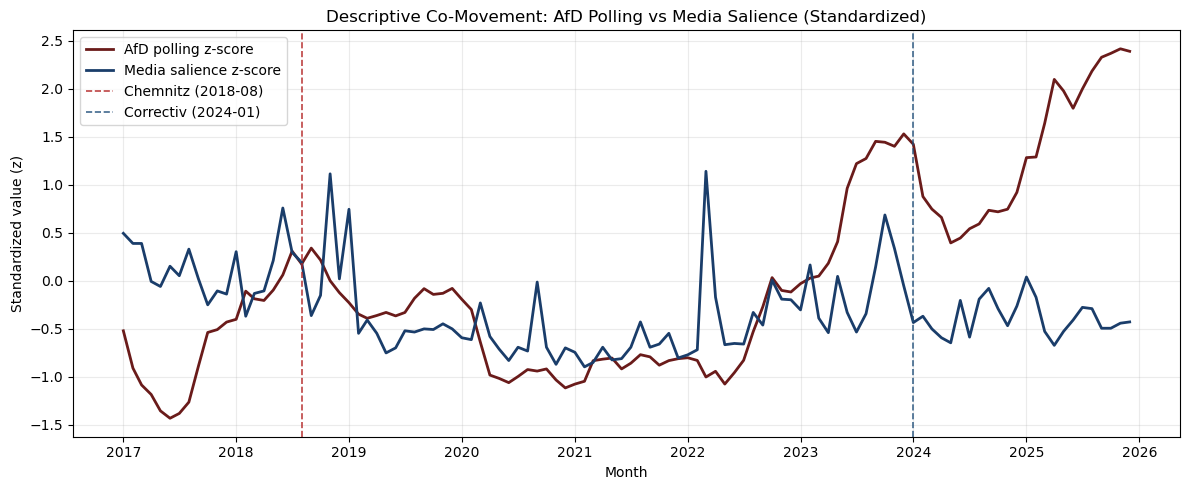

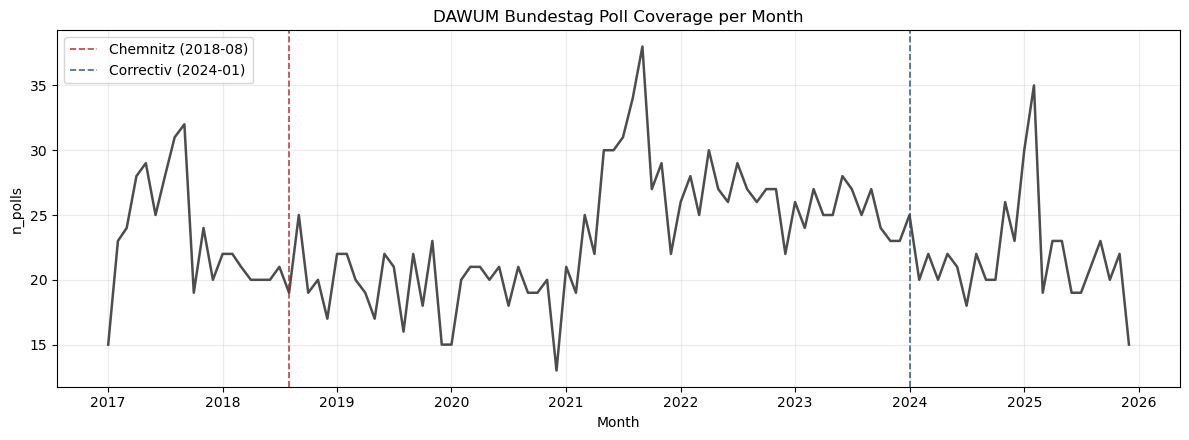

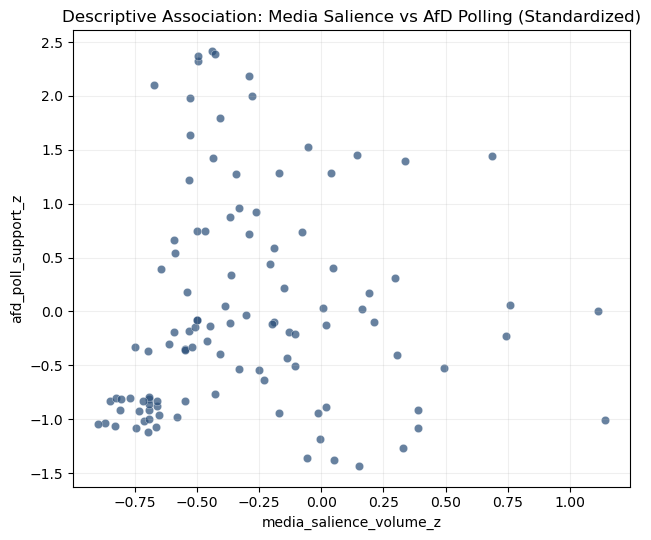

In [16]:
def add_shock_lines(ax):
    ax.axvline(CHEMNITZ_MONTH, color='#b22222', linestyle='--', linewidth=1.2, alpha=0.85, label='Chemnitz (2018-08)')
    ax.axvline(CORRECTIV_MONTH, color='#1f4e79', linestyle='--', linewidth=1.2, alpha=0.85, label='Correctiv (2024-01)')

                                
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(panel['month_dt'], panel['afd_poll_support_mean'], color='#3b2f2f', linewidth=2)
add_shock_lines(ax)
ax.set_title('AfD Bundestag Polling Support by Month (Descriptive)')
ax.set_xlabel('Month')
ax.set_ylabel('AfD polling support (%)')
ax.grid(alpha=0.25)
ax.legend(loc='upper left')
fig.tight_layout()
out1 = FIGURES_DIR / 'afd_poll_support_monthly.png'
fig.savefig(out1, dpi=150)
plt.show()

                             
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(panel['month_dt'], panel['nexis_total_results'], color='#2f5d50', linewidth=2)
add_shock_lines(ax)
ax.set_title('Monthly Nexis Total Results (Media Salience Volume)')
ax.set_xlabel('Month')
ax.set_ylabel('Nexis total results')
ax.grid(alpha=0.25)
ax.legend(loc='upper left')
fig.tight_layout()
out2 = FIGURES_DIR / 'media_salience_monthly_nexis_total.png'
fig.savefig(out2, dpi=150)
plt.show()

                             
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(panel['month_dt'], panel['afd_poll_support_z'], color='#6a1b1a', linewidth=2, label='AfD polling z-score')
ax.plot(panel['month_dt'], panel['media_salience_volume_z'], color='#1a3d6a', linewidth=2, label='Media salience z-score')
add_shock_lines(ax)
ax.set_title('Descriptive Co-Movement: AfD Polling vs Media Salience (Standardized)')
ax.set_xlabel('Month')
ax.set_ylabel('Standardized value (z)')
ax.grid(alpha=0.25)
ax.legend(loc='upper left')
fig.tight_layout()
out3 = FIGURES_DIR / 'descriptive_comovement_standardized.png'
fig.savefig(out3, dpi=150)
plt.show()

                              
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(panel['month_dt'], panel['n_polls'], color='#4d4d4d', linewidth=1.8)
add_shock_lines(ax)
ax.set_title('DAWUM Bundestag Poll Coverage per Month')
ax.set_xlabel('Month')
ax.set_ylabel('n_polls')
ax.grid(alpha=0.25)
ax.legend(loc='upper left')
fig.tight_layout()
out4 = FIGURES_DIR / 'n_polls_per_month.png'
fig.savefig(out4, dpi=150)
plt.show()

                                             
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(panel['media_salience_volume_z'], panel['afd_poll_support_z'], alpha=0.7, color='#274c77', edgecolor='white', linewidth=0.3)
ax.set_title('Descriptive Association: Media Salience vs AfD Polling (Standardized)')
ax.set_xlabel('media_salience_volume_z')
ax.set_ylabel('afd_poll_support_z')
ax.grid(alpha=0.2)
fig.tight_layout()
out5 = FIGURES_DIR / 'scatter_media_vs_polling_z.png'
fig.savefig(out5, dpi=150)
plt.show()

In [17]:




chem_window = panel[(panel['month_dt'] >= pd.Timestamp('2018-05-01')) & (panel['month_dt'] <= pd.Timestamp('2018-11-01'))]
cor_window = panel[(panel['month_dt'] >= pd.Timestamp('2023-10-01')) & (panel['month_dt'] <= pd.Timestamp('2024-04-01'))]
cols = ['year_month', 'nexis_total_results', 'media_salience_volume_z', 'afd_poll_support_mean', 'n_polls']

In [18]:
preferred_front = [
    'month', 'year_month', 'month_dt', 'year', 'month_num',
    'afd_poll_support_mean', 'afd_poll_support_median', 'afd_poll_support_sd',
    'n_polls', 'n_pollsters',
    'nexis_total_results', 'media_salience_volume_raw', 'media_salience_volume_log1p', 'media_salience_volume_z',
    'afd_poll_support_z',
    'raw_article_count', 'download_fraction', 'kept_article_count', 'cleaned_sample_size', 'cleaned_sample_fraction',
    'retrieval_mismatch_flag', 'high_download_sample_flag',
    'source'
]

existing_front = [c for c in preferred_front if c in panel.columns]
other_cols = [c for c in panel.columns if c not in existing_front]
panel_out = panel[existing_front + other_cols].copy()

panel_out.to_csv(PANEL_CSV_PATH, index=False)
panel_out.to_parquet(PANEL_PARQUET_PATH, index=False)